# Forecasting Model
Build and train forecasting models for trade flow prediction.

In [4]:
!python -m pip install prophet


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np
from prophet import Prophet
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(
    '../data/processed/clean_cargo_trends.csv',
    parse_dates=['Record_Date'])

print("Shape:", df.shape)
display(df.head())

c:\Users\offic\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


Shape: (3291, 13)


,Record_Date,Year,Month,Day,Port_Region,Cargo_Type,Import_Volume_MMT,Export_Volume_MMT,Total_Volume_MMT,Vessel_Arrival_Count,Avg_Berth_Turnaround_Days,Month_Year,month_num
0,2023-06-01,2023,6,1,Gujarat Coast (Hazira/Mundra),Container Tonnage,0.085,0.069,0.154,2,1.23,2023-06,6
1,2023-06-01,2023,6,1,Gujarat Coast (Hazira/Mundra),Dry Bulk (Coal/Minerals),0.044,0.047,0.091,0,0.00,2023-06,6
2,2023-06-01,2023,6,1,Gujarat Coast (Hazira/Mundra),Liquid Cargo (POL/Crude),0.032,0.034,0.066,1,2.45,2023-06,6
3,2023-06-02,2023,6,2,Gujarat Coast (Hazira/Mundra),Container Tonnage,0.099,0.081,0.180,2,1.28,2023-06,6
4,2023-06-02,2023,6,2,Gujarat Coast (Hazira/Mundra),Dry Bulk (Coal/Minerals),0.056,0.061,0.117,1,1.92,2023-06,6


In [6]:
# Prophet requires exactly 2 columns:
# 'ds' (datestamp) and 'y' (value)

# Aggregate to monthly total volume
monthly = (df.groupby(
    df['Record_Date'].dt.to_period('M'))
    ['Total_Volume_MMT']
    .sum()
    .reset_index())

monthly.columns = ['ds', 'y']
monthly['ds'] = monthly[
    'ds'].dt.to_timestamp()

# Remove partial 2026 months
# Keep only complete months
monthly = monthly[
    monthly['ds'] < '2026-06-01']

print("Training data shape:", monthly.shape)
print("Date range:",
      monthly['ds'].min(), "to",
      monthly['ds'].max())
display(monthly.tail())

Training data shape: (36, 2)
Date range: 2023-06-01 00:00:00 to 2026-05-01 00:00:00


,ds,y
31,2026-01-01,14.760
32,2026-02-01,14.239
33,2026-03-01,14.068
34,2026-04-01,14.994
35,2026-05-01,15.101


In [7]:
# Initialize Prophet with port-specific
# seasonality settings
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.05
)

# Fit model on historical data
model.fit(monthly)

print("Model trained successfully")
print(f"Training period: "
      f"{monthly['ds'].min().date()} "
      f"to {monthly['ds'].max().date()}")
print(f"Total months trained on: "
      f"{len(monthly)}")

22:41:37 - cmdstanpy - INFO - Chain [1] start processing
22:41:38 - cmdstanpy - INFO - Chain [1] done processing


Model trained successfully
Training period: 2023-06-01 to 2026-05-01
Total months trained on: 36


In [8]:
# Create dataframe for future dates
# 3 months forward (July-Sept 2026)
future = model.make_future_dataframe(
    periods=3,
    freq='MS')  # Month Start frequency

print("Future dataframe tail:")
display(future.tail(6))

# Generate forecast
forecast = model.predict(future)

# Key columns in forecast output:
# ds = date
# yhat = predicted value
# yhat_lower = lower confidence bound
# yhat_upper = upper confidence bound
print("\nForecast output columns:")
print(list(forecast.columns))

Future dataframe tail:


,ds
33,2026-03-01
34,2026-04-01
35,2026-05-01
36,2026-06-01
37,2026-07-01
38,2026-08-01



Forecast output columns:
['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper', 'multiplicative_terms', 'multiplicative_terms_lower', 'multiplicative_terms_upper', 'yearly', 'yearly_lower', 'yearly_upper', 'additive_terms', 'additive_terms_lower', 'additive_terms_upper', 'yhat']


In [9]:
# Show actual vs predicted
results = forecast[
    ['ds', 'yhat', 'yhat_lower',
     'yhat_upper']].copy()
results.columns = [
    'Month', 'Predicted_Volume',
    'Lower_Bound', 'Upper_Bound']
results['Predicted_Volume'] = (
    results['Predicted_Volume']
    .round(3))
results['Lower_Bound'] = (
    results['Lower_Bound'].round(3))
results['Upper_Bound'] = (
    results['Upper_Bound'].round(3))

# Show last 6 rows (3 historical +
# 3 forecast months)
print("=== 3-Month Forecast ===")
display(results.tail(6))

# Highlight just the forecast months
forecast_only = results.tail(3)
print("\n=== New Predictions ===")
for _, row in forecast_only.iterrows():
    print(f"{row['Month'].strftime('%B %Y')}: "
          f"{row['Predicted_Volume']} MMT "
          f"(Range: {row['Lower_Bound']}"
          f" – {row['Upper_Bound']})")

=== 3-Month Forecast ===


,Month,Predicted_Volume,Lower_Bound,Upper_Bound
33,2026-03-01,14.256,13.936,14.594
34,2026-04-01,15.103,14.777,15.443
35,2026-05-01,15.020,14.657,15.359
36,2026-06-01,12.378,12.034,12.731
37,2026-07-01,12.760,12.410,13.116
38,2026-08-01,12.520,12.176,12.883



=== New Predictions ===
June 2026: 12.378 MMT (Range: 12.034 – 12.731)
July 2026: 12.76 MMT (Range: 12.41 – 13.116)
August 2026: 12.52 MMT (Range: 12.176 – 12.883)


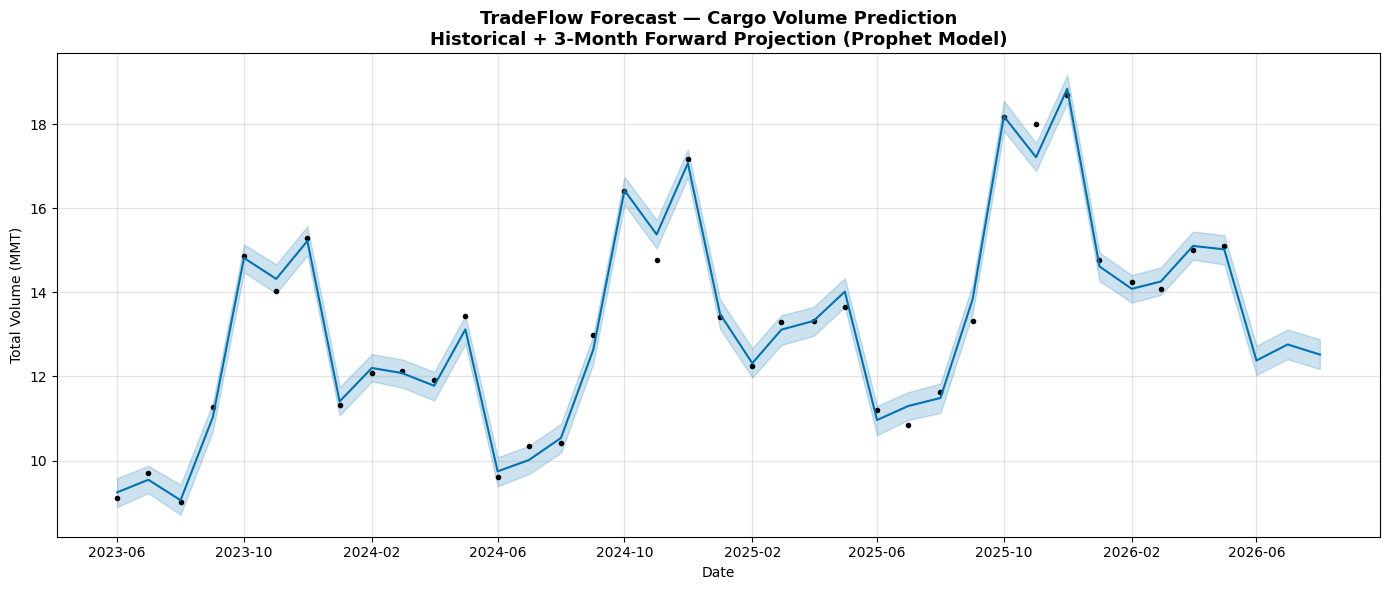

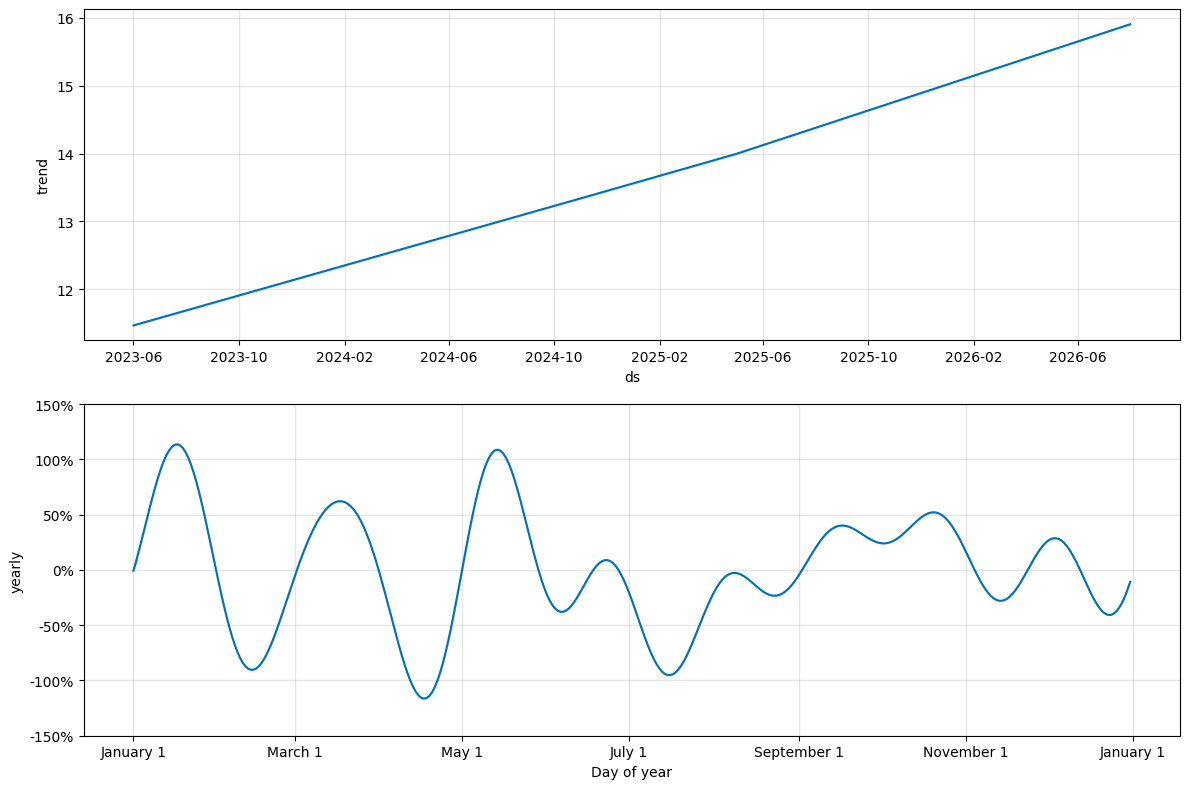

In [10]:
fig1 = model.plot(forecast,
                   figsize=(14, 6))

plt.title(
    'TradeFlow Forecast — '
    'Cargo Volume Prediction\n'
    'Historical + 3-Month Forward '
    'Projection (Prophet Model)',
    fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Volume (MMT)')
plt.tight_layout()
plt.savefig(
    '../assets/prophet_forecast.png',
    dpi=150, bbox_inches='tight')
plt.show()

# Plot components separately
# (trend + yearly seasonality)
fig2 = model.plot_components(forecast,
                              figsize=(12, 8))
plt.tight_layout()
plt.savefig(
    '../assets/prophet_components.png',
    dpi=150, bbox_inches='tight')
plt.show()

In [11]:
from sklearn.metrics import (
    mean_absolute_error)

# Compare actual vs predicted
# on HISTORICAL data only
historical = forecast[
    forecast['ds'] <= monthly['ds'].max()]

actual = monthly['y'].values
predicted = historical['yhat'].values[
    :len(actual)]

mae = mean_absolute_error(
    actual, predicted)
mape = np.mean(
    np.abs((actual - predicted)
           / actual)) * 100

print("=== Model Evaluation ===")
print(f"MAE:  {mae:.2f} MMT")
print(f"MAPE: {mape:.2f}%")
print()
if mape < 15:
    print("MAPE < 15% — "
          "Good forecast accuracy")
elif mape < 25:
    print("MAPE 15-25% — "
          "Acceptable for monthly "
          "cargo forecasting")
else:
    print("MAPE > 25% — "
          "Consider tuning model")

# Save results
results.to_csv(
    '../data/processed/'
    'forecast_results.csv',
    index=False)
print("\nForecast saved to "
      "data/processed/forecast_results.csv")

=== Model Evaluation ===
MAE:  0.20 MMT
MAPE: 1.52%

MAPE < 15% — Good forecast accuracy

Forecast saved to data/processed/forecast_results.csv
